
# Tesla EV Analytics & Forecasting
## End-to-End Machine Learning Pipeline (2015–2025)

This notebook covers:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting
- Model evaluation
- Final insights and conclusions


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA


## Load Dataset

In [2]:

# Replace with your actual dataset path
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Overview

In [3]:

print("Shape:", df.shape)

df.info()


Shape: (2640, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [4]:

df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:

df.isnull().sum()


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

## Data Cleaning & Preprocessing

In [6]:

# Create Date Column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [7]:

# Encode categorical columns

categorical_cols = ['Region', 'Model', 'Source_Type']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


## Feature Engineering

In [8]:

# Delivery Efficiency
df['Delivery_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

# Price Per KM
df['Price_per_KM'] = df['Avg_Price_USD'] / df['Range_km']

# CO2 Saved Per Vehicle
df['CO2_per_Vehicle'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']

# Yearly Production Growth
df['Yearly_Production_Growth'] = df['Production_Units'].pct_change()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Efficiency,Price_per_KM,CO2_per_Vehicle,Yearly_Production_Growth
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,0.984600,131.923679,0.105600,NaN
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,0.911864,142.022032,0.065699,-0.767660
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,0.915334,245.598583,0.072000,1.206772
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,0.896594,125.414199,0.106799,-0.204375
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,0.914087,173.747020,0.099150,0.851593


In [9]:
print(df.isnull().sum())

Year                        0
Month                       0
Region                      0
Model                       0
Estimated_Deliveries        0
Production_Units            0
Avg_Price_USD               0
Battery_Capacity_kWh        0
Range_km                    0
CO2_Saved_tons              0
Source_Type                 0
Charging_Stations           0
Date                        0
Delivery_Efficiency         0
Price_per_KM                0
CO2_per_Vehicle             0
Yearly_Production_Growth    1
dtype: int64


In [10]:
df.fillna(0, inplace=True)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Efficiency,Price_per_KM,CO2_per_Vehicle,Yearly_Production_Growth
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,0.984600,131.923679,0.105600,0.000000
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,0.911864,142.022032,0.065699,-0.767660
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,0.915334,245.598583,0.072000,1.206772
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,0.896594,125.414199,0.106799,-0.204375
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,0.914087,173.747020,0.099150,0.851593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,2,4,13488,14333,113771.10,120,719,1454.68,2,4273,2021-10-01,0.941045,158.235188,0.107850,-0.163964
2636,2019,7,2,2,18300,18407,81889.67,82,487,1336.81,2,9833,2019-07-01,0.994187,168.151273,0.073050,0.284239
2637,2019,9,0,2,13291,14839,97139.38,100,580,1156.32,0,13709,2019-09-01,0.895680,167.481690,0.087000,-0.193839
2638,2020,5,0,0,3471,3714,69990.57,60,358,186.39,1,6754,2020-05-01,0.934572,195.504385,0.053699,-0.749714


## Exploratory Data Analysis (EDA)

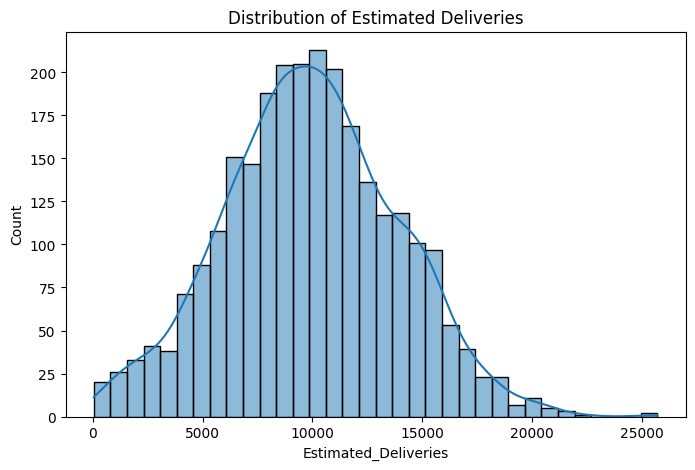

In [11]:

plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.title('Distribution of Estimated Deliveries')
plt.show()


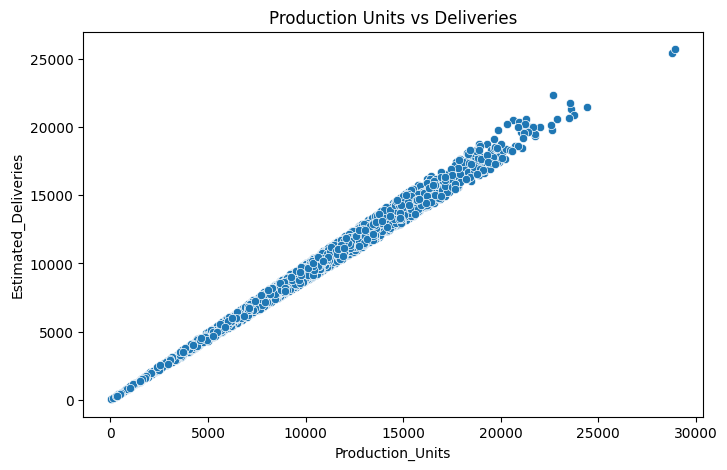

In [12]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df)
plt.title('Production Units vs Deliveries')
plt.show()


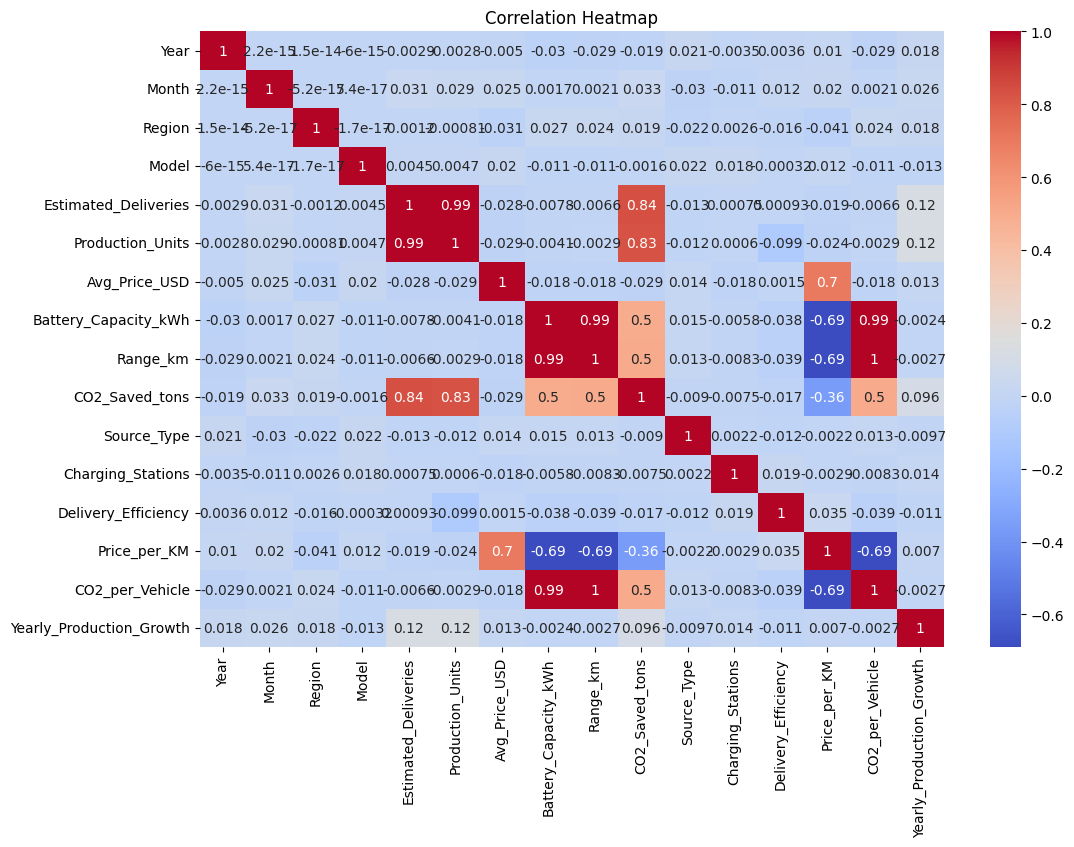

In [13]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


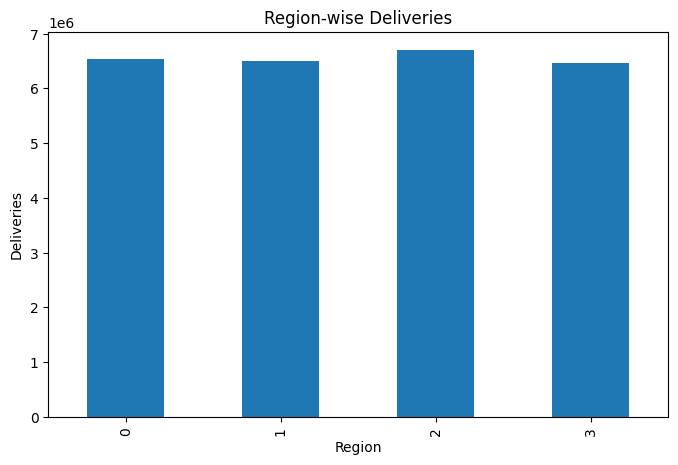

In [14]:

plt.figure(figsize=(8,5))
df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar')
plt.title('Region-wise Deliveries')
plt.ylabel('Deliveries')
plt.show()


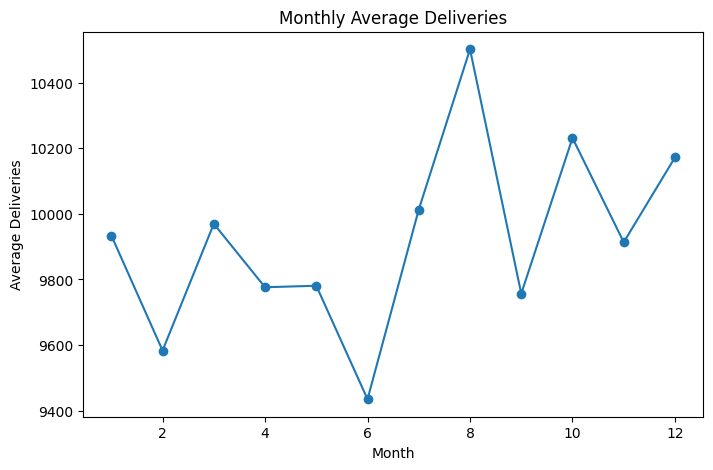

In [15]:

monthly_sales = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Average Deliveries')
plt.ylabel('Average Deliveries')
plt.show()


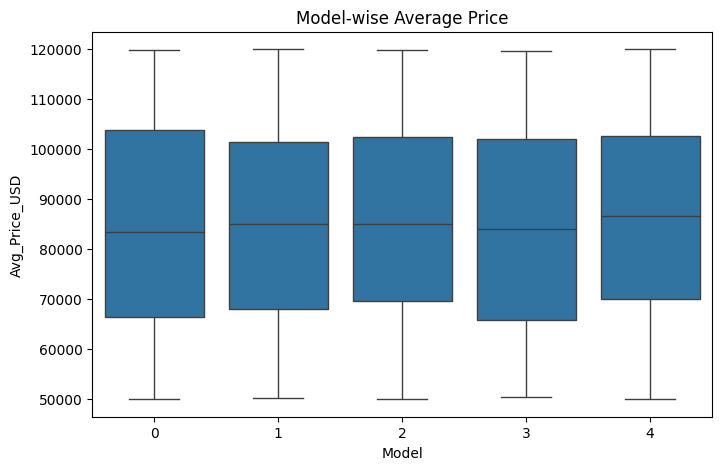

In [16]:

plt.figure(figsize=(8,5))
sns.boxplot(x='Model', y='Avg_Price_USD', data=df)
plt.title('Model-wise Average Price')
plt.show()


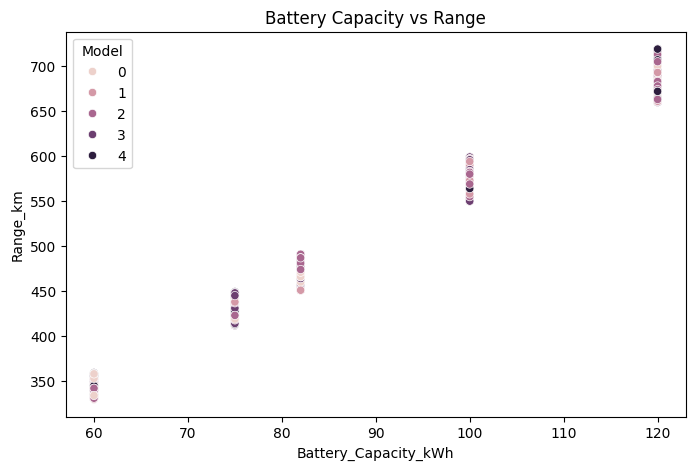

In [17]:

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Battery_Capacity_kWh',
    y='Range_km',
    hue='Model',
    data=df
)
plt.title('Battery Capacity vs Range')
plt.show()


## Machine Learning Pipeline

In [18]:

# Define Features and Target

X = df.drop(['Estimated_Deliveries', 'Date'], axis=1)
y = df['Estimated_Deliveries']


In [19]:

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(2112, 15)
(528, 15)


In [20]:

# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Linear Regression

In [21]:

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)


MAE: 108.87305263917384
RMSE: 153.25360657974124
R2 Score: 0.998424378509335


## Random Forest Regressor

In [22]:

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


MAE: 68.74428030303031
RMSE: 113.70365628699145
R2 Score: 0.9991326800249021


## Gradient Boosting Regressor

In [23]:

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)


MAE: 71.68419850158156
RMSE: 100.03210684001417
R2 Score: 0.9993287113257829


## Hyperparameter Tuning

In [24]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9980308984604443


## Feature Importance

In [25]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance


,Feature,Importance
4,Production_Units,0.990355
11,Delivery_Efficiency,0.008633
8,CO2_Saved_tons,0.000242
12,Price_per_KM,0.000114
5,Avg_Price_USD,0.000090
14,Yearly_Production_Growth,0.000088
10,Charging_Stations,0.000087
0,Year,0.000077
1,Month,0.000063
2,Region,0.000051


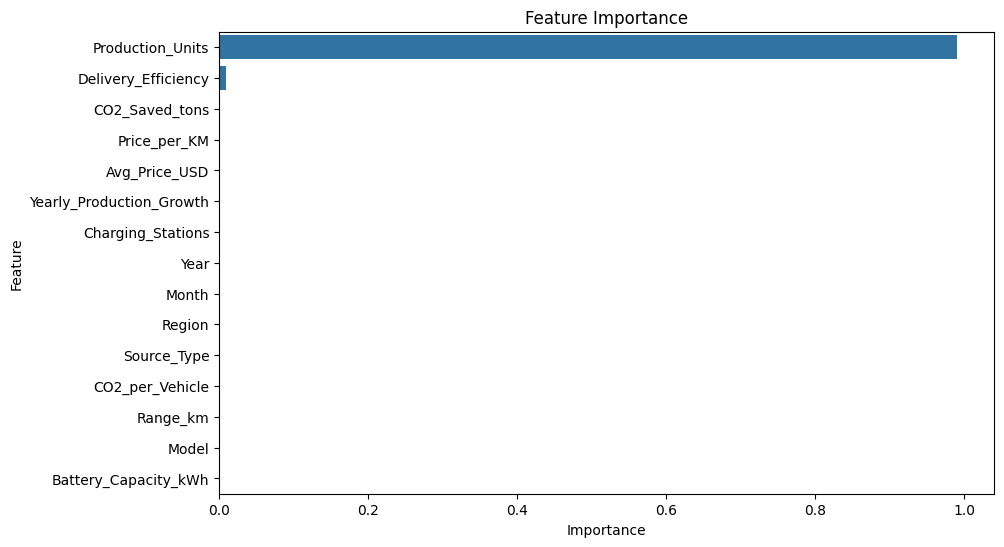

In [26]:

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()


## Time Series Forecasting

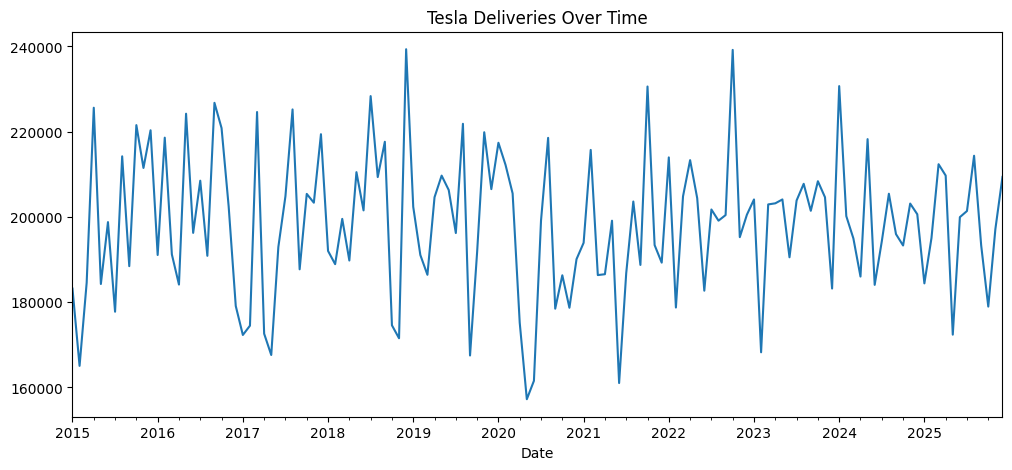

In [27]:

ts = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))
ts.plot()
plt.title('Tesla Deliveries Over Time')
plt.show()


In [28]:

model = ARIMA(ts, order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

forecast


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    203819.655291
2026-02-01    202894.176206
2026-03-01    199011.662570
2026-04-01    198667.010481
2026-05-01    200971.493836
2026-06-01    201391.449841
2026-07-01    201412.663908
2026-08-01    201031.409116
2026-09-01    200601.086697
2026-10-01    200710.068210
2026-11-01    200864.721557
2026-12-01    200936.680131
Freq: MS, Name: predicted_mean, dtype: float64

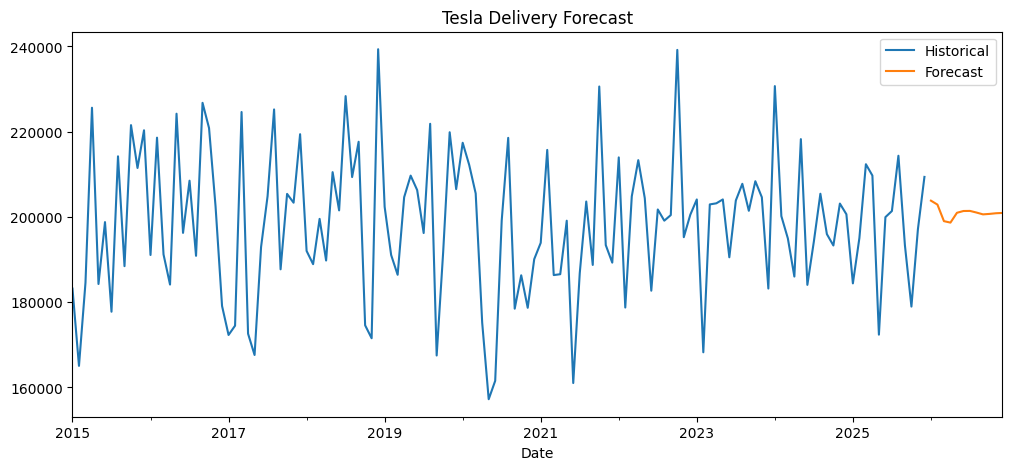

In [29]:

plt.figure(figsize=(12,5))

ts.plot(label='Historical')
forecast.plot(label='Forecast')

plt.legend()
plt.title('Tesla Delivery Forecast')
plt.show()


## Model Comparison

In [30]:

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
})

comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,108.873053,153.253607,0.998424
1,Random Forest,68.744280,113.703656,0.999133
2,Gradient Boosting,71.684199,100.032107,0.999329
